In [210]:
!pip install qutip

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from qutip import (basis, destroy, mesolve, qeye, tensor, create, sigmaz, sigmam, sigmap, fock, Qobj, fidelity, Options)
from scipy.signal import find_peaks

from scipy.interpolate import CubicSpline
!pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.plots import plot_convergence
from skopt.utils import use_named_args

from skopt.plots import plot_convergence, plot_objective, plot_evaluations

In [164]:
wc = wa = 1.0  # Example values
w0 = wc # resonance driving
delta_c = (wc - w0)/wc
delta_a = (wa - w0)/wc
g = 0.01 * wc

sigma_z_np = np.array([[1 , 0],
                   [0, -1]])
sigma_z_alt = Qobj(sigma_z_np)
sigma_plus_np = np.array([[0, 1],
                   [0, 0]])
sigma_plus_alt = Qobj(sigma_plus_np)
sigma_minus_np = np.transpose(sigma_plus_np)
sigma_minus_alt = Qobj(sigma_minus_np)

spin_down = fock(2, 1)
spin_up = fock(2, 0)

# 1 down

In [165]:
# Hilbert space dimension for the cavity
n_cavity_1d = 5

In [166]:
###########################
# Define the Operators
###########################

sigma_minus = tensor(qeye(n_cavity_1d), sigma_minus_alt) # atomic lowering operator
sigma_plus =  tensor(qeye(n_cavity_1d), sigma_plus_alt)  # atomic raising operator
sigma_z = tensor(qeye(n_cavity_1d), sigma_z_alt)     # atomic z operator
a = tensor(destroy(n_cavity_1d), qeye(2))   # cavity annihilation operator

In [167]:
# Define initial and target states for 1d setup
psi_1d = tensor(fock(n_cavity_1d, 0), spin_down)
psi_den_1d = psi_1d * psi_1d.dag()
target_state_1d = tensor(fock(n_cavity_1d, 1), spin_down)
target_den_1d = target_state_1d * target_state_1d.dag()

In [168]:
# Time-dependent driving function for 1d
def f_t_1d(t, args_1d):
    frequency_1d = args_1d['frequencies']
    envelope_func_1d = args_1d['spline']

    return envelope_func_1d(t) * np.cos(frequency_1d * t)

In [169]:
from skopt import gp_minimize
from skopt.space import Real

# Global variable to store the final state at the minimum
best_final_rho_1d = None
final_rho_global_1d = None

# Custom simple callback (no subclassing)
# Custom simple callback (no subclassing)
def custom_callback_1d(result):
    global best_final_rho_1d

    x_1d = result.x_iters[-1]
    y_1d = result.func_vals[-1]

    current_min_idx_1d = int(result.func_vals.argmin())
    best_x_1d = result.x_iters[current_min_idx_1d]
    best_y_1d = result.func_vals[current_min_idx_1d]

    print(f"\nIteration No: {len(result.x_iters)} ended.")
    print(f"Function value obtained: {y_1d:.6f}")
    print(f"Simulation time used: {x_1d[-1]:.2f}")
    print(f"Current minimum: {best_y_1d:.6f}")
    print(f"Simulation time at current minimum: {best_x_1d[-1]:.2f}")
    print('-' * 50)

    # Evaluate and store final state at current best
    frequency_1d, envelope_y_value_1d, envelope_x_value_1d, Y2_1d, X2_1d, sim_time_1d = best_x_1d
    fid_value_1d = -objective_general_1d(frequency_1d, envelope_y_value_1d, envelope_x_value_1d, Y2_1d, X2_1d, sim_time_1d)
    best_final_rho_1d = final_rho_global_1d
    print(f"Updated best_final_rho_1d with fidelity: {fid_value_1d:.6f}")

# Your objective function
# Your objective function
def objective_general_1d(frequency_1d, envelope_y_value_1d, envelope_x_value_1d, Y2_1d, X2_1d, sim_time_1d):
    global final_rho_global_1d

    if (envelope_x_value_1d >= sim_time_1d) or (envelope_x_value_1d <= 0):
        return float('0')
    elif X2_1d >= sim_time_1d or X2_1d <= 0:
        return float('0')
    elif X2_1d <= envelope_x_value_1d:
        return float('0')

    tau_1d = wc * sim_time_1d
    envelope_values_1d = [0, envelope_y_value_1d, Y2_1d, 0]
    control_times_1d = [0, envelope_x_value_1d, X2_1d, tau_1d]
    spline_1d = CubicSpline(control_times_1d, envelope_values_1d, extrapolate=False)

    args_1d = {
        'frequencies': frequency_1d,
        'spline': spline_1d,
        'sim_time': sim_time_1d
    }

    H_static_1d = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
    H_drive_1d = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
    H_1d = [H_static_1d, H_drive_1d]

    result_1d = mesolve(H_1d, psi_den_1d, [0, tau_1d], c_ops=[], e_ops=[], options={'nsteps': int(1e9), 'atol': 1e-7, 'rtol': 1e-7}, args=args_1d)
    final_rho_1d = result_1d.states[-1]

    final_rho_global_1d = final_rho_1d  # store globally

    # Compute fidelity as overlap with pure target state
    fid_1d = fidelity(final_rho_1d, target_state_1d)
    return -fid_1d

def objective_1d(x_1d):
    return objective_general_1d(x_1d[0], x_1d[1], x_1d[2], x_1d[3], x_1d[4], x_1d[-1])

# Define the parameter space for Bayesian Optimization
space_1d = [
    Real(0.01, 0.05, name='frequency_1d'),
    Real(-g, g, name='envelope_y_value_1d'),
    Real(10, 1000, name='envelope_x_value_1d'),
    Real(-g, g, name='Y2_1d'),
    Real(20, 2500, name='X2_1d'),
    Real(100, 3000, name='sim_time_1d')
]

# Run the optimization
res_1d = gp_minimize(
    objective_1d,
    space_1d,
    n_calls=250,
    random_state=42,
    verbose=False,
    acq_func='EI',
    callback=[custom_callback_1d]
)


Iteration No: 1 ended.
Function value obtained: 0.000000
Simulation time used: 389.93
Current minimum: 0.000000
Simulation time at current minimum: 389.93
--------------------------------------------------
Updated best_final_rho_1d with fidelity: -0.000000

Iteration No: 2 ended.
Function value obtained: -0.216608
Simulation time used: 2193.80
Current minimum: -0.216608
Simulation time at current minimum: 2193.80
--------------------------------------------------
Updated best_final_rho_1d with fidelity: 0.216608

Iteration No: 3 ended.
Function value obtained: 0.000000
Simulation time used: 120.49
Current minimum: -0.216608
Simulation time at current minimum: 2193.80
--------------------------------------------------
Updated best_final_rho_1d with fidelity: 0.216608

Iteration No: 4 ended.
Function value obtained: 0.000000
Simulation time used: 775.04
Current minimum: -0.216608
Simulation time at current minimum: 2193.80
--------------------------------------------------
Updated best_

In [170]:
# Trace out the atom to get the reduced state of the cavity (1d case)
rho_cavity_1d = best_final_rho_1d.ptrace(0)

# Diagonal elements: populations of Fock states
photon_populations_1d = np.real(np.diag(rho_cavity_1d.full()))

for n_1d, p_1d in enumerate(photon_populations_1d):
    if p_1d > 0.001:
        print(f"Fock state |{n_1d}⟩ (1d): population = {p_1d:.4f}")

Fock state |0⟩ (1d): population = 0.0111
Fock state |1⟩ (1d): population = 0.9813
Fock state |2⟩ (1d): population = 0.0076


In [171]:
# Define target state: |1⟩ ⊗ |↓⟩ for the 1d setup
target_state_1d = tensor(fock(n_cavity_1d, 1), spin_down)

# Manual fidelity computation: Tr[rho ⋅ target_density]
rho_array_1d = best_final_rho_1d.full()
target_array_1d = target_state_1d.full()

manual_fid_1d = np.trace(rho_array_1d @ target_array_1d).real

print(f"Manual fidelity calculation (_1d): {manual_fid_1d:.6f}")

Manual fidelity calculation (_1d): 0.000000


In [172]:
from qutip import fidelity

fid_qutip_1d = fidelity(best_final_rho_1d, target_state_1d)

print(f"QuTiP fidelity (_1d): {fid_qutip_1d:.6f}")

QuTiP fidelity (_1d): 0.990541


In [173]:
# Manual (pure target case)
manual_fid = np.real(target_state_1d.dag() * best_final_rho_1d * target_state_1d)

# Or use trace if using density matrix
manual_fid_dm = np.trace(best_final_rho_1d.full() @ target_density_1d.full()).real

# QuTiP (can use vector or density)
fid_qutip = fidelity(target_state_1d, best_final_rho_1d)  # or target_density_1d

print(f"Manual: {manual_fid:.6f}")
print(f"Manual (density): {manual_fid_dm:.6f}")
print(f"QuTiP: {fid_qutip:.6f}")

Manual: 0.981171
Manual (density): 0.981171
QuTiP: 0.990541


QuTiP gives a slightly higher value due to purification overlap

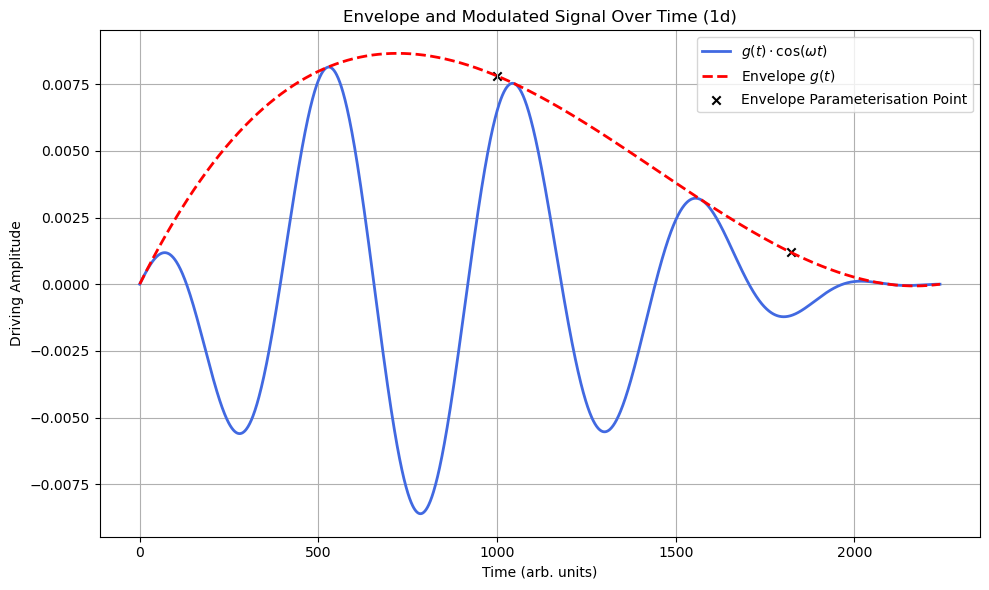

In [140]:
# Assuming 'res_1d' holds the results from Bayesian optimization and contains optimal values
optimal_frequency_1d = res_1d.x[0]
optimal_envelope_value_1d = res_1d.x[1]
optimal_envelope_x_value_1d = res_1d.x[2]
optimal_Y2_1d = res_1d.x[3]
optimal_X2_1d = res_1d.x[4]
optimal_sim_time_1d = res_1d.x[-1]

# Define the envelope function using optimal parameters (1d)
envelope_values_1d = [0, optimal_envelope_value_1d, optimal_Y2_1d, 0]
control_times_1d = [0, optimal_envelope_x_value_1d, optimal_X2_1d, optimal_sim_time_1d]
spline_1d = CubicSpline(control_times_1d, envelope_values_1d, extrapolate=False)

# Time array for the simulation (1d)
tau_1d = np.linspace(0, wc * optimal_sim_time_1d, 2000)

# Evaluate envelope and modulated waveform
envelope_1d = spline_1d(tau_1d)
cosine_wave_1d = np.cos(optimal_frequency_1d * tau_1d)
modulated_wave_1d = envelope_1d * cosine_wave_1d

# Plotting (1d)
plt.figure(figsize=(10, 6))
plt.plot(tau_1d, modulated_wave_1d, label='$g(t) \\cdot \\cos(\\omega t)$', linewidth=2, color='royalblue')
plt.plot(tau_1d, envelope_1d, label='Envelope $g(t)$', linestyle='--', color='red', linewidth=2)
plt.scatter([optimal_envelope_x_value_1d, optimal_X2_1d], 
            [optimal_envelope_value_1d, optimal_Y2_1d], 
            marker='x', color='black', label='Envelope Parameterisation Point')
plt.title('Envelope and Modulated Signal Over Time (1d)')
plt.xlabel('Time (arb. units)')
plt.ylabel('Driving Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

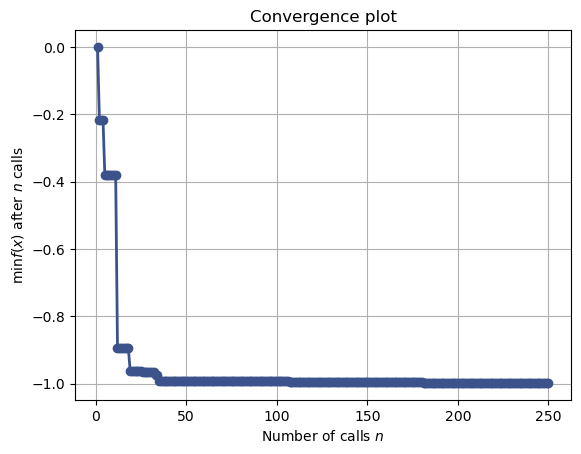

In [141]:
plot_convergence(res_1d)
plt.show()

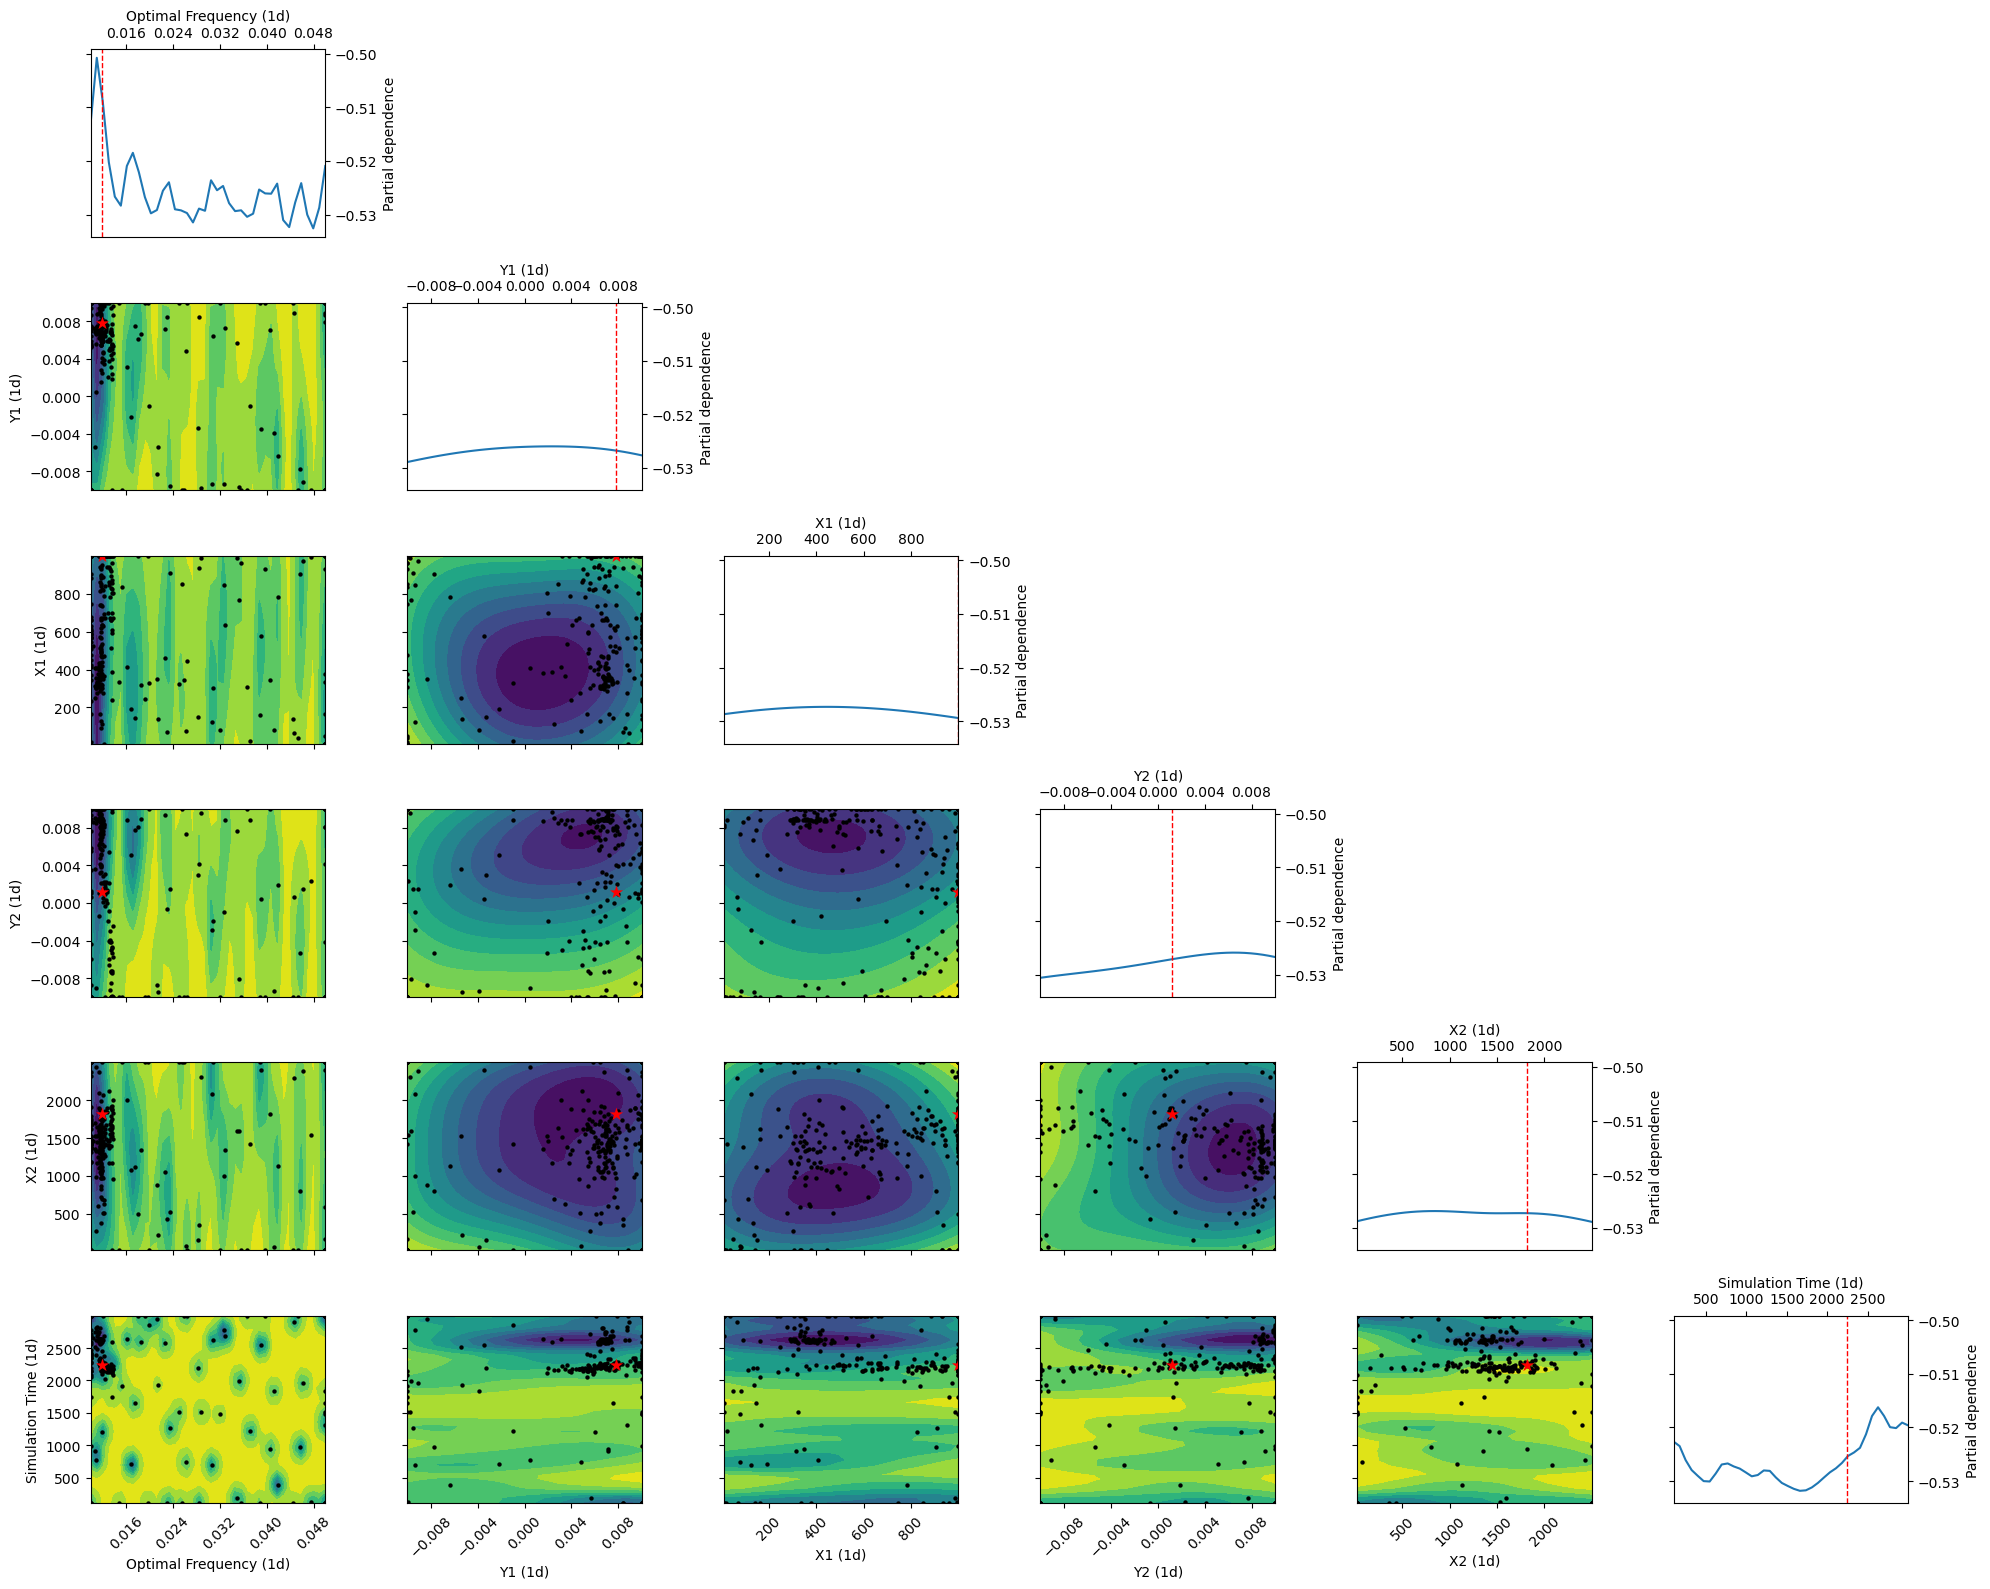

In [142]:
fig_1d, ax_1d = plt.subplots(figsize=(20, 16))  # You can adjust the dimensions as needed
plot_objective(res_1d, dimensions=['Optimal Frequency (1d)', 'Y1 (1d)', 'X1 (1d)', 'Y2 (1d)', 'X2 (1d)', 'Simulation Time (1d)'], ax=ax_1d)
plt.tight_layout()
plt.show()

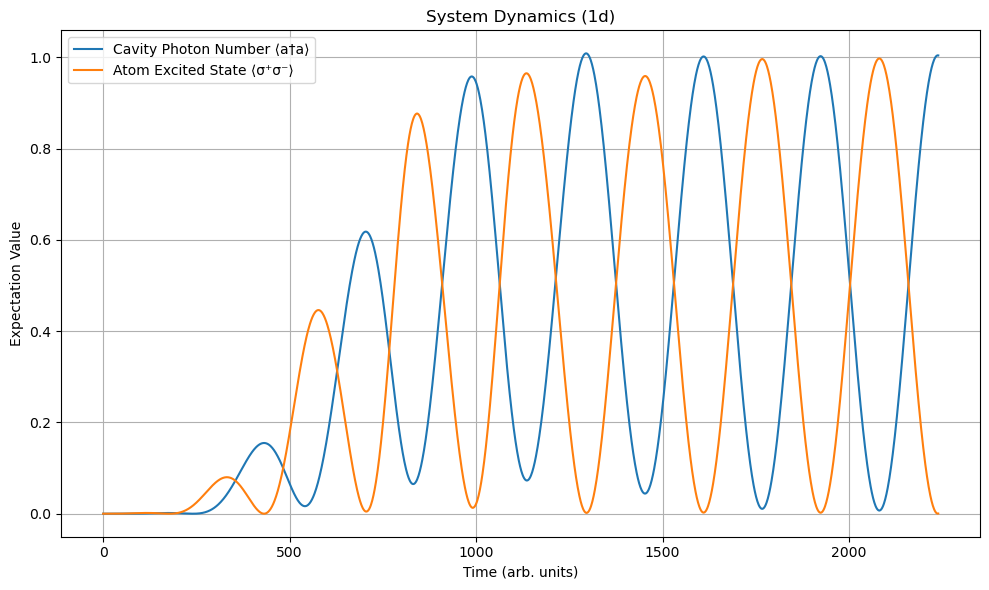

In [143]:
# Define initial state (1d case)
psi_1d = tensor(fock(n_cavity_1d, 0), spin_down)

# Define args dictionary with optimal parameters (1d)
args_1d = {'frequencies': optimal_frequency_1d, 'spline': spline_1d}

# Time-dependent driving term (1d)
H_drive_1d = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t_1d(t, args)]
H_static_1d = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
H_1d = [H_static_1d, H_drive_1d]

# Time array for simulation (if not already defined)
tau_1d = np.linspace(0, wc * optimal_sim_time_1d, 2000)

# Solve dynamics using mesolve (1d)
output_1d = mesolve(H_1d, psi_1d, tau_1d, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args_1d)

# Extract expectations (1d)
n_c_1d = output_1d.expect[0]  # Cavity photon number ⟨a†a⟩
n_a_1d = output_1d.expect[1]  # Atom excited state population ⟨σ⁺σ⁻⟩

# Plot dynamics (1d)
plt.figure(figsize=(10, 6))
plt.plot(tau_1d, n_c_1d, label='Cavity Photon Number ⟨a†a⟩')
plt.plot(tau_1d, n_a_1d, label='Atom Excited State ⟨σ⁺σ⁻⟩')
plt.grid(True)
plt.xlabel('Time (arb. units)')
plt.ylabel('Expectation Value')
plt.title('System Dynamics (1d)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [25]:
frequency_bare = 2 * g * np.sqrt(1)
print(f'The bare frequency is {frequency_bare:.3f}')
print(f'The driven frequency is {res.x[0]:.3f}')

The bare frequency is 0.020
The driven frequency is 0.012


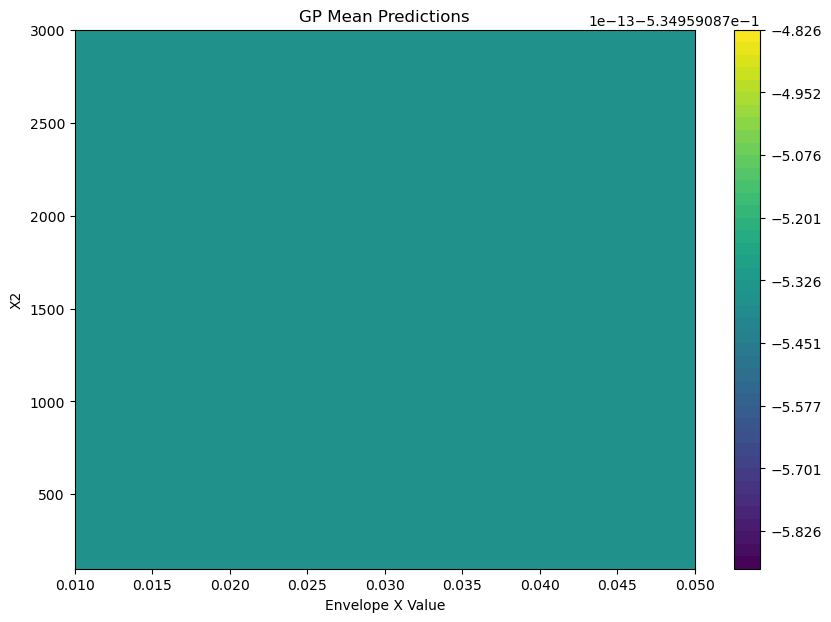

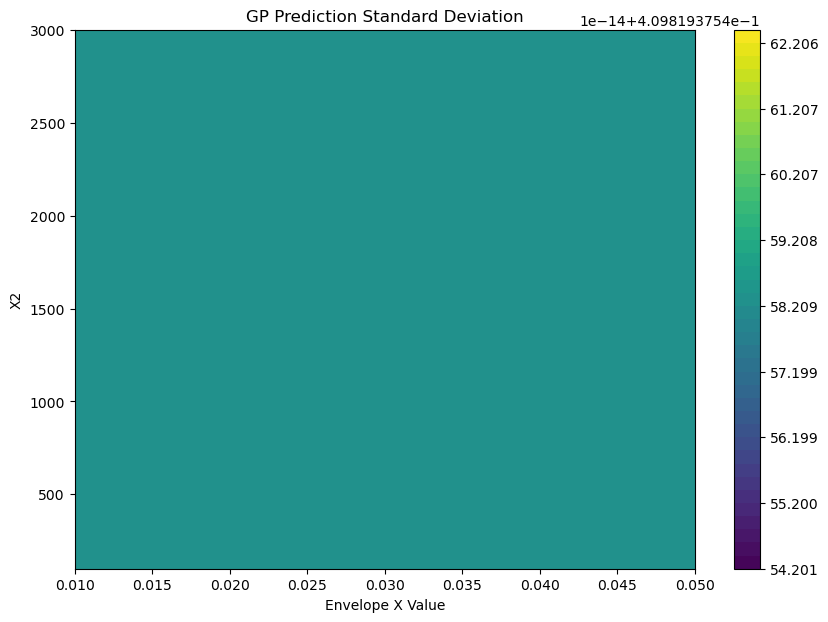

In [26]:
gp = res.models[-1]

# Optimal values from Bayesian optimization
optimal_values = res.x

# Choose indices for the dimensions to vary (e.g., envelope_x_value and X2)
index1, index2 = 0, 5  # Corresponding to 'envelope_x_value' and 'X2'

# Prepare the grid
x = np.linspace(space[index1].bounds[0], space[index1].bounds[1], 50)
y = np.linspace(space[index2].bounds[0], space[index2].bounds[1], 50)
X, Y = np.meshgrid(x, y)

# Prepare full samples grid
full_samples = np.tile(optimal_values, (X.size, 1))
full_samples[:, index1] = X.ravel()  # Update the grid values for first varying dimension
full_samples[:, index2] = Y.ravel()  # Update the grid values for second varying dimension

# Predict using the GP model
means, stds = gp.predict(full_samples, return_std=True)

# Reshape for plotting
Z = means.reshape(X.shape)
Std_dev = stds.reshape(X.shape)

# Plotting the mean predictions
plt.figure(figsize=(10, 7))
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.xlabel('Envelope X Value')
plt.ylabel('X2')
plt.title('GP Mean Predictions')
plt.show()

# Plotting the uncertainty
plt.figure(figsize=(10, 7))
contour = plt.contourf(X, Y, Std_dev, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.xlabel('Envelope X Value')
plt.ylabel('X2')
plt.title('GP Prediction Standard Deviation')
plt.show()

## Fidelity and Infedelity in log scale

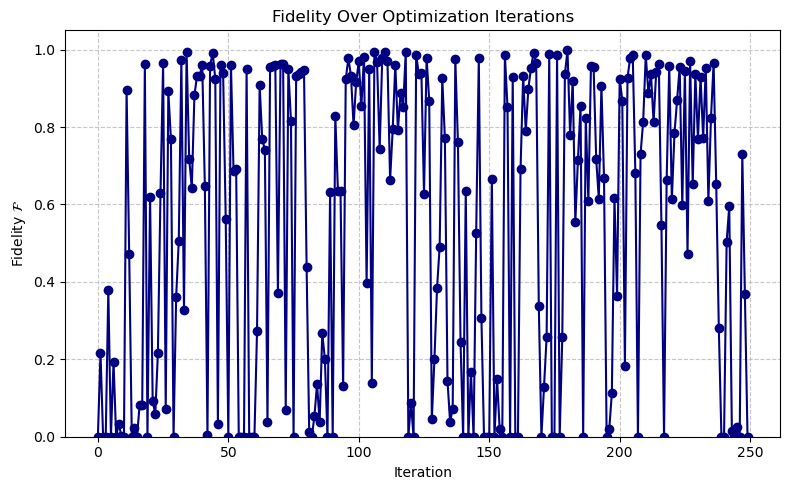

In [27]:
# Extract fidelity from negative objective values
fidelities = [-fval for fval in res.func_vals]  # since obj = -fidelity

# Plot fidelity over iterations
plt.figure(figsize=(8, 5))
plt.plot(fidelities, marker='o', linestyle='-', color='navy')
plt.xlabel('Iteration')
plt.ylabel('Fidelity $\\mathcal{F}$')
plt.title('Fidelity Over Optimization Iterations')
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

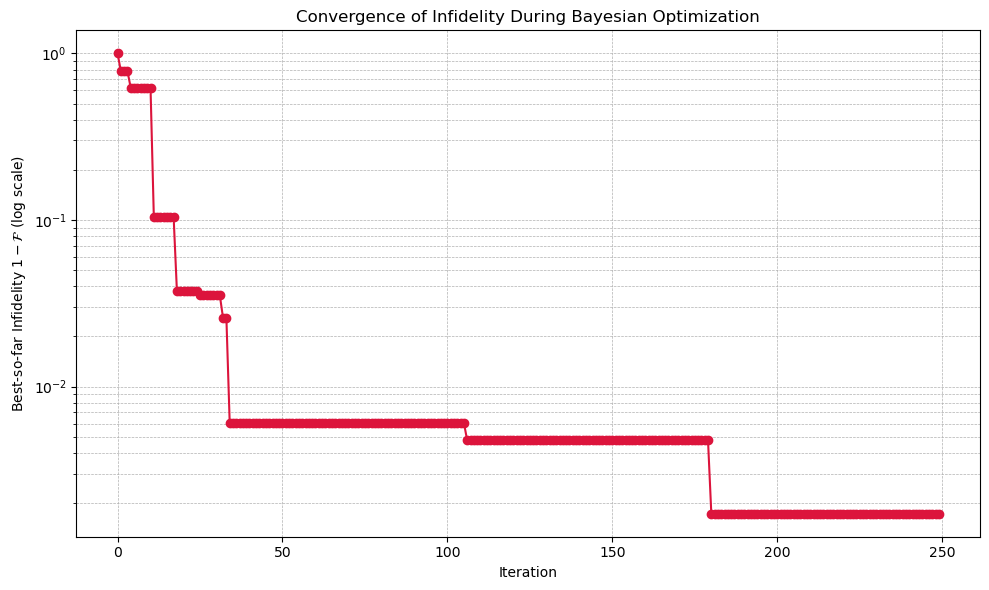

In [28]:
# Extract negative fidelities and compute infidelities
negative_fidelities = np.array(res.func_vals)  # Values are -fidelity
fidelities = -negative_fidelities
infidelities = 1 - fidelities

# Replace zero infidelity with epsilon to avoid log(0)
infidelities[infidelities == 0] = np.finfo(float).eps

# Compute the best (lowest) infidelity so far at each iteration
best_so_far_infidelity = np.minimum.accumulate(infidelities)

# Plot: Convergence of best infidelity
plt.figure(figsize=(10, 6))
plt.semilogy(best_so_far_infidelity, marker='o', linestyle='-', color='crimson')
plt.title("Convergence of Infidelity During Bayesian Optimization")
plt.xlabel("Iteration")
plt.ylabel("Best-so-far Infidelity $1 - \\mathcal{F}$ (log scale)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


\subsection{Log-Scaled Infidelity Analysis}

Figure~\ref{fig:infidelity_log} displays the evolution of the infidelity $1 - \mathcal{F}$ throughout the course of Bayesian optimization, plotted on a logarithmic scale to resolve the wide dynamic range of the fidelity landscape. The use of a $\log_{10}$ scale is essential in this context, as infidelity values span multiple orders of magnitude—from $\mathcal{O}(10^{-1})$ in early iterations to as low as $\mathcal{O}(10^{-3})$ in the vicinity of convergence.

The scatter in the plot reflects the stochastic sampling nature of the optimization process, which explores both high- and low-performing regions of the parameter space. Despite this variance, the lower envelope of the curve exhibits a clear downward trend, signifying systematic fidelity improvement. Notably, high-fidelity regions with infidelity $< 10^{-2}$ begin to emerge within the first 50 iterations, consistent with the convergence behavior observed in the fidelity plot (Figure~\ref{fig:convergence}).

This representation confirms the effectiveness of the optimization strategy in discovering control parameters that yield near-unit fidelity, and highlights the sensitivity of the system to suboptimal parameter regimes, which frequently result in infidelity close to unity. The log scaling thus not only visualizes optimization efficiency but also underscores the importance of precision control in quantum state engineering.


In [29]:
\begin{figure}[htbp]
\centering
\includegraphics[width=0.85\textwidth]{adf7875a-54f0-4391-828d-be55724c7c34.png}
\caption{Logarithmic-scale plot of the infidelity $1 - \mathcal{F}$ over Bayesian optimization iterations. Lower values correspond to higher overlap between the final quantum state and the target state $|1,\downarrow\rangle$.}
\label{fig:infidelity_log}
\end{figure}

SyntaxError: unexpected character after line continuation character (399332744.py, line 1)

## Rabi to frequency detuning

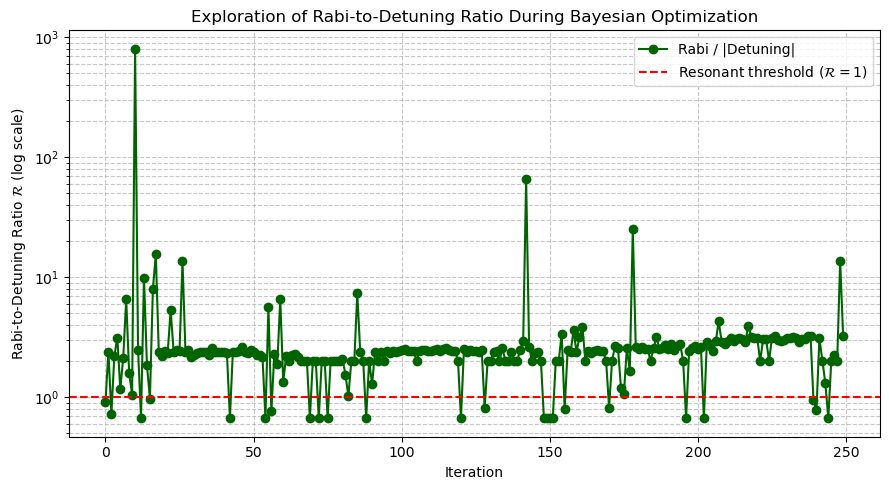

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
g = 0.01
omega_bare = 2 * g * np.sqrt(1)  # fixed analytical value

# Extract all proposed frequencies from optimizer
frequencies = [x[0] for x in res.x_iters]  # assuming first parameter is frequency

# Compute detunings and ratios over iterations
detunings = np.abs(omega_bare - np.array(frequencies))
rabi_freq = omega_bare
ratios = rabi_freq / detunings

# Plot the ratio over iterations
plt.figure(figsize=(9, 5))
plt.plot(ratios, marker='o', linestyle='-', color='darkgreen', label='Rabi / |Detuning|')
plt.axhline(1.0, color='red', linestyle='--', label='Resonant threshold ($\\mathcal{R}=1$)')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Rabi-to-Detuning Ratio $\\mathcal{R}$ (log scale)')
plt.title('Exploration of Rabi-to-Detuning Ratio During Bayesian Optimization')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.7)
plt.tight_layout()
plt.show()

\subsection{Exploration of Rabi-to-Detuning Ratio}

Figure~\ref{fig:rabi_detuning} illustrates the optimization trajectory in terms of the Rabi-to-detuning ratio, defined as
\[
\mathcal{R} = \frac{2g\sqrt{1}}{|\omega_{\text{bare}} - \omega|},
\]
where $\omega_{\text{bare}} = 2g$ is the analytic Jaynes–Cummings transition frequency for the $|0,\downarrow\rangle \rightarrow |1,\downarrow\rangle$ transition, and $\omega$ denotes the drive frequency sampled at each optimization step.

The plot, presented on a logarithmic scale, reveals that the optimizer initially explores a wide range of values, including both resonant ($\mathcal{R} > 1$) and dispersive ($\mathcal{R} < 1$) regimes. During the early phase (iterations $\sim$ 10–60), the algorithm samples extremely high $\mathcal{R}$ values, corresponding to near-resonant conditions or even accidental degeneracies due to vanishing detuning. However, as the optimization progresses, the sampled frequencies begin to cluster in the range $0.010$–$0.015$, leading to a sustained region of $\mathcal{R} \approx 1$, which reflects the optimizer's convergence toward a physically meaningful balance between coherent exchange and detuned robustness.

This behavior is consistent with the principle that maximum fidelity does not necessarily occur exactly at resonance, particularly in the presence of shaped driving envelopes. The envelope function $h(\tau)$ induces dressed-state effects and Floquet sidebands, effectively enabling transitions at off-resonant drive frequencies. Therefore, the observed stabilization of $\mathcal{R}$ near unity confirms the system's preference for slightly detuned, spectrally broadened excitation pathways over strict resonance, optimizing both robustness and controllability.

In [31]:
\begin{figure}[htbp]
\centering
\includegraphics[width=0.85\textwidth]{a9c65306-0019-4ab7-8028-76d0dc22b393.png}
\caption{Log-scale plot of the Rabi-to-detuning ratio $\mathcal{R} = \Omega_{\text{Rabi}} / |\Delta|$ across Bayesian optimization à
iterations. The dashed red line denotes the resonance threshold at $\mathcal{R} = 1$.}
\label{fig:rabi_detuning}
\end{figure}

SyntaxError: unexpected character after line continuation character (745227490.py, line 1)

In [34]:
# Constants
g = 0.01
omega_bare = 2 * g * np.sqrt(1)  # for transition 1↓ -> 2↓

# Extract optimal frequency from optimization result
optimal_frequency = res.x[0]

# Compute detuning and Rabi/Detuning ratio
detuning_optimal = np.abs(omega_bare - optimal_frequency)
rabi_freq = omega_bare
ratio_optimal = rabi_freq / detuning_optimal

# Print everything
print(f"\nOptimal results:")
print(f"Optimal frequency: {optimal_frequency:.5f}")
print(f"Corresponding simulation time: {res.x[-1]:.2f}")
print(f"Rabi frequency: {rabi_freq:.5f}")
print(f"Detuning at optimal point: {detuning_optimal:.5f}")
print(f"Rabi-to-Detuning ratio at optimal point: {ratio_optimal:.5f}")



Optimal results:
Optimal frequency: 0.01198
Corresponding simulation time: 2239.32
Rabi frequency: 0.02000
Detuning at optimal point: 0.00802
Rabi-to-Detuning ratio at optimal point: 2.49294


# 5 Down

In [175]:
n_cavity_5d = 7

psi = tensor(fock(n_cavity_5d, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity_5d, 5), spin_down)
target_den = target_state * target_state.dag()

In [176]:
###########################
# Define the Operators
###########################

sigma_z_np = np.array([[1 , 0],
                   [0, -1]])
sigma_z_alt = Qobj(sigma_z_np)
sigma_plus_np = np.array([[0, 1],
                   [0, 0]])
sigma_plus_alt = Qobj(sigma_plus_np)
sigma_minus_np = np.transpose(sigma_plus_np)
sigma_minus_alt = Qobj(sigma_minus_np)

sigma_minus = tensor(qeye(n_cavity_5d), sigma_minus_alt) # atomic lowering operator
sigma_plus =  tensor(qeye(n_cavity_5d), sigma_plus_alt)  # atomic raising operator
sigma_z = tensor(qeye(n_cavity_5d), sigma_z_alt)     # atomic z operator
a = tensor(destroy(n_cavity_5d), qeye(2))   # cavity annihilation operator
spin_down = fock(2, 1)
spin_up = fock(2, 0)

wc = wa = 1.0  # Example values
w0 = wc # resonance driving
delta_c = (wc - w0)/wc
delta_a = (wa - w0)/wc
g = 0.01 * wc

In [177]:
from skopt import gp_minimize
from skopt.space import Real

# Global variable to store the final state at the minimum
best_final_rho = None

# Custom simple callback (no subclassing)
def custom_callback(result):
    global best_final_rho  # this will store the final state at the best point

    x = result.x_iters[-1]    # Last evaluated parameters
    y = result.func_vals[-1]  # Last evaluated function value

    current_min_idx = int(result.func_vals.argmin())
    best_x = result.x_iters[current_min_idx]
    best_y = result.func_vals[current_min_idx]

    print(f"\nIteration No: {len(result.x_iters)} ended.")
    print(f"Function value obtained: {y:.6f}")
    print(f"Simulation time used: {x[-1]:.2f}")
    print(f"Current minimum: {best_y:.6f}")
    print(f"Simulation time at current minimum: {best_x[-1]:.2f}")
    print('-' * 50)

    # Update best_final_rho at the current minimum
    frequency, envelope_y_value, envelope_x_value, Y2, X2, sim_time = best_x
    fid_value = -objective_general(frequency, envelope_y_value, envelope_x_value, Y2, X2, sim_time)
    best_final_rho = final_rho_global  # gets updated by objective_general
    print(f"Updated best_final_rho with fidelity: {fid_value:.6f}")

# Your objective function
def objective_general(frequency, envelope_y_value, envelope_x_value, Y2, X2, sim_time):
    global final_rho_global  # declare as global so we can store it

    if (envelope_x_value >= sim_time) or (envelope_x_value <= 0):
        return float('0')
    elif X2 >= sim_time or X2 <= 0:
        return float('0')
    elif X2 <= envelope_x_value:
        return float('0')

    tau = wc * sim_time
    envelope_values = [0, envelope_y_value, Y2, 0]
    control_times = [0, envelope_x_value, X2, tau]
    spline = CubicSpline(control_times, envelope_values, extrapolate=False)

    args = {
        'frequencies': frequency,
        'spline': spline,
        'sim_time': sim_time
    }

    H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
    H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t: f_t(t, args)]
    H = [H_static, H_drive]

    result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[], options={'nsteps': int(1e9), 'atol': 1e-7, 'rtol': 1e-7}, args=args)
    final_rho = result.states[-1]

    final_rho_global = final_rho  # save it globally

    fid = fidelity(final_rho, target_den)
    return -fid

def objective(x):
    return objective_general(x[0], x[1], x[2], x[3], x[4], x[-1])

# Parameter space
space = [
    Real(0.01, 0.05, name='frequency'),
    # spline amplitudes: a bit larger than ±g to leave room for sign flips
    Real(-1.5*g, 1.5*g,         name='envelope_y_value'),
    Real(  100,   1230,           name='envelope_x_value'),
    Real(-1.5*g, 1.5*g,         name='Y2'),
    Real( 200, 2180,           name='X2'),
    Real( 500,   6000,           name='sim_time')
]

# Run optimization
res = gp_minimize(
    objective,
    space,
    n_calls=50,
    random_state=42,
    verbose=False,  # <<< OFF
    acq_func='EI',
    callback=[custom_callback]  # <<< Only custom callback
)


Iteration No: 1 ended.
Function value obtained: 0.000000
Simulation time used: 1049.86
Current minimum: 0.000000
Simulation time at current minimum: 1049.86
--------------------------------------------------
Updated best_final_rho with fidelity: -0.000000
 ZVODE--  Warning: internal T (=R1) and H (=R2) are
       such that in the machine, T + H = T on the next step  
       (H = step size). solver will continue anyway

Iteration No: 2 ended.
Function value obtained: -0.033333
Simulation time used: 4470.99
Current minimum: -0.033333
Simulation time at current minimum: 4470.99
--------------------------------------------------
      In above,  R1 =  0.4470993247468D+04   R2 =  0.4291035817787D-12
 ZVODE--  Warning: internal T (=R1) and H (=R2) are
       such that in the machine, T + H = T on the next step  
       (H = step size). solver will continue anyway
      In above,  R1 =  0.4470993247468D+04   R2 =  0.4291035817787D-12
 ZVODE--  Above warning has been issued I1 times.  
      

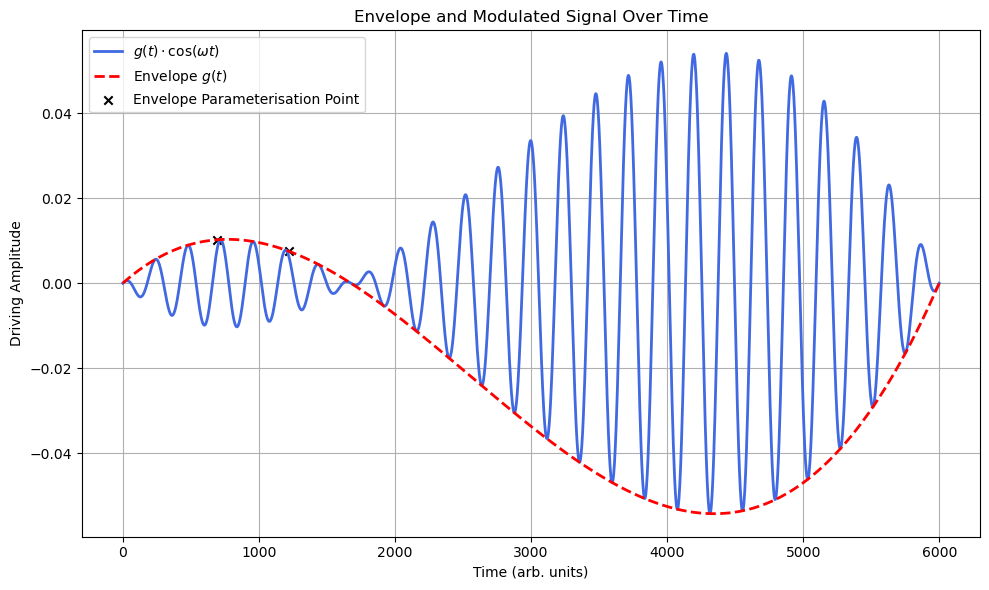

In [179]:
# Assuming 'res' holds the results from Bayesian optimization and contains optimal values
optimal_frequency = res.x[0]
optimal_envelope_value = res.x[1]
optimal_envelope_x_value = res.x[2]
optimal_Y2 = res.x[3]
optimal_X2 = res.x[4]
optimal_sim_time = res.x[-1]

# Define the envelope function using optimal parameters
envelope_values = [0, optimal_envelope_value, optimal_Y2, 0]
control_times = [0, optimal_envelope_x_value, optimal_X2, optimal_sim_time]
spline = CubicSpline(control_times, envelope_values, extrapolate=False)

# Time array for the simulation, using the optimal simulation time
tau = np.linspace(0, wc * optimal_sim_time, 2000)

envelope = spline(tau)
cosine_wave = np.cos(optimal_frequency * tau)
modulated_wave = envelope * cosine_wave

# Plotting the envelope and the modulated signal
plt.figure(figsize=(10, 6))
plt.plot(tau, modulated_wave, label='$g(t) \\cdot \\cos(\\omega t)$', linewidth=2, color ='royalblue')
plt.plot(tau, envelope, label='Envelope $g(t)$', linestyle='--',color='red', linewidth=2)
plt.scatter(control_times[1:3], envelope_values[1:3], marker = 'x', color = 'black', label = 'Envelope Parameterisation Point')
plt.title('Envelope and Modulated Signal Over Time')
plt.xlabel('Time (arb. units)')
plt.ylabel('Driving Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

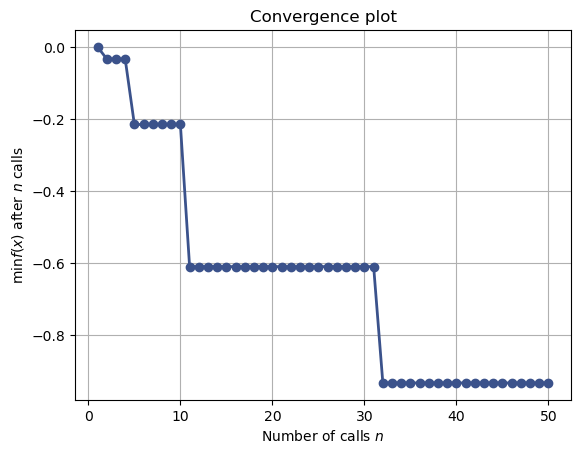

In [180]:
plot_convergence(res)
plt.show()

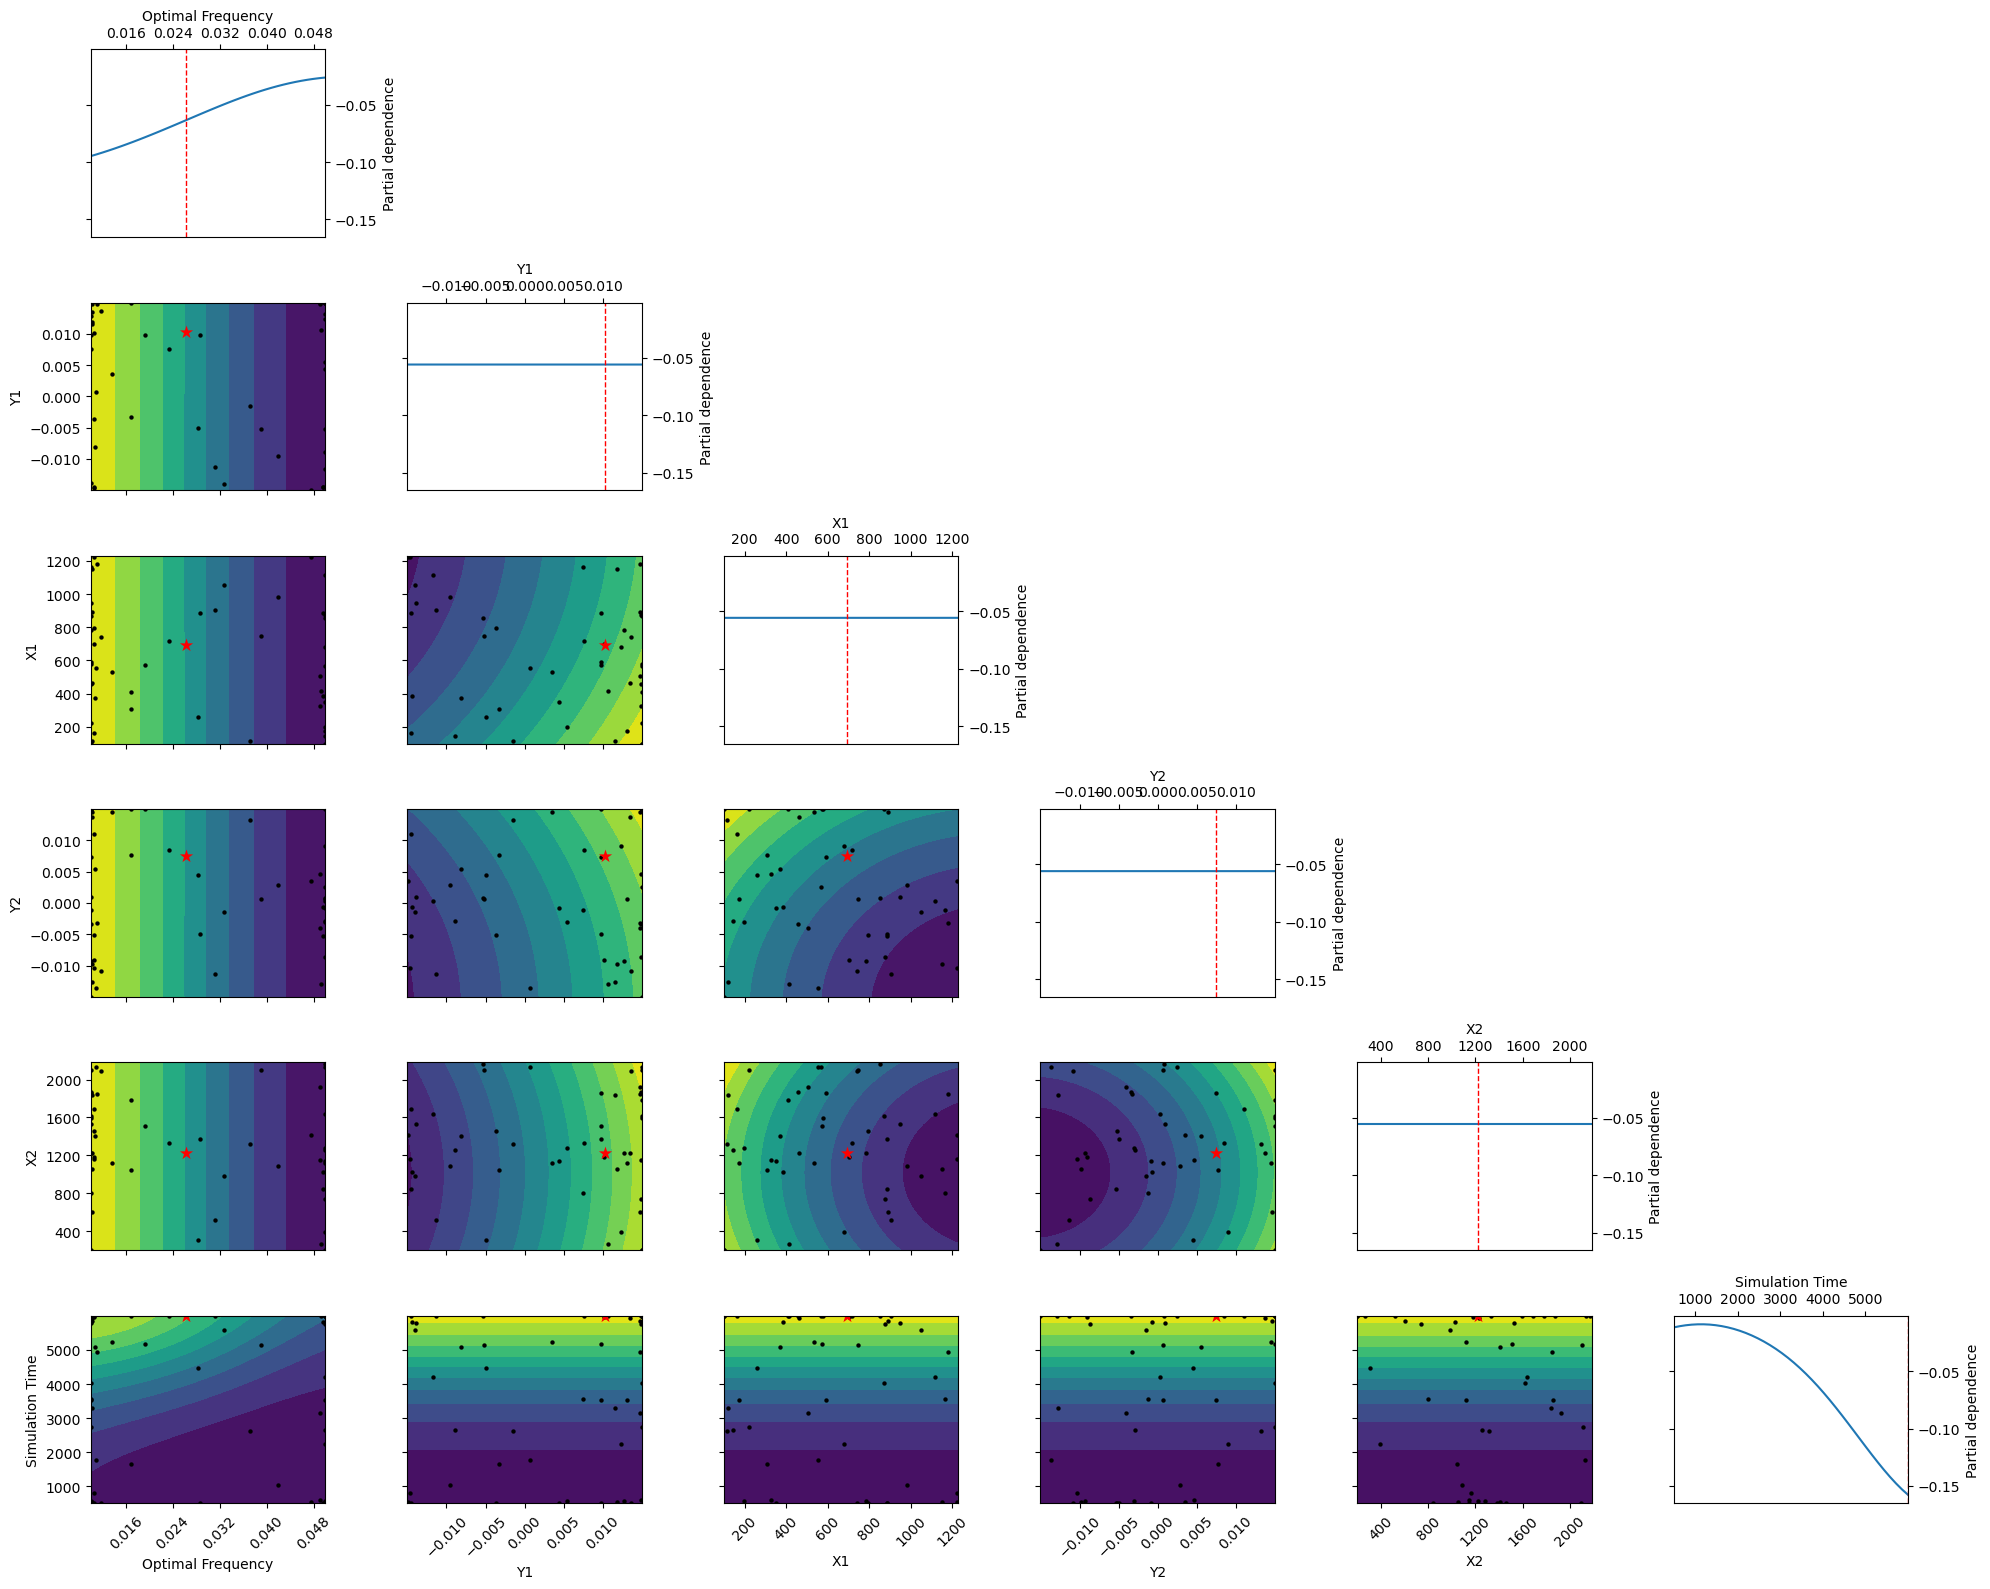

In [181]:
fig, ax = plt.subplots(figsize=(20, 16))  # You can adjust the dimensions as needed
plot_objective(res, dimensions=['Optimal Frequency', 'Y1', 'X1', 'Y2', 'X2', 'Simulation Time'], ax=ax)
plt.tight_layout()
plt.show()

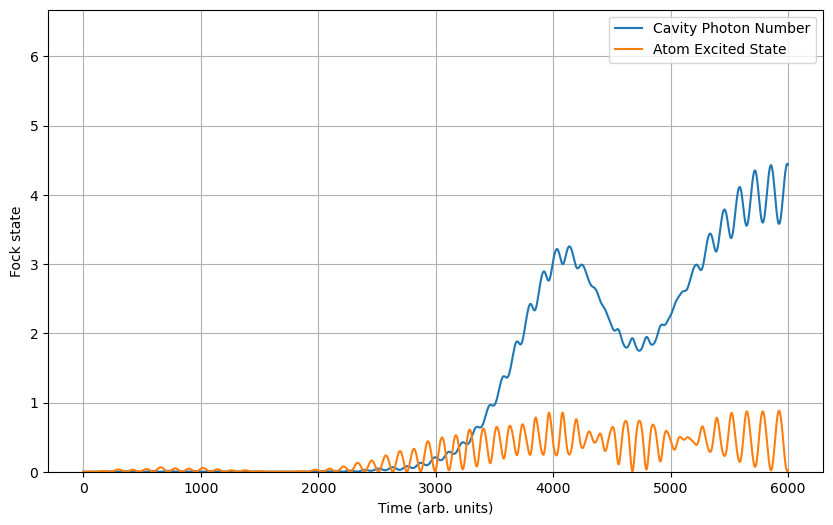

In [196]:
psi = tensor(fock(n_cavity_5d, 0), spin_down)

args = {'frequencies': optimal_frequency, 'spline': spline}

# Time-dependent driving term
H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
H = [H_static, H_drive]

output = mesolve(H, psi, tau, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args)

n_c = output.expect[0]
n_a = output.expect[1]


plt.figure(figsize=(10,6))
plt.plot(tau, n_c, label = 'Cavity Photon Number')
plt.plot(tau, n_a, label = 'Atom Excited State')
plt.grid(True)
plt.xlabel('Time (arb. units)')
plt.ylabel('Fock state')
plt.legend(loc='best')

# Increase y-axis height by 10%
y_max = max(max(n_c), max(n_a))
plt.ylim(0, y_max * 1.5)

plt.show()

In [214]:
from qutip import destroy

# Assume cavity Hilbert space has dimension N
N = rho_cavity.shape[0]
a_cavity = destroy(N)
n_operator = a_cavity.dag() * a_cavity

# Now compute expectation value
expected_photon_number = expect(n_operator, rho_cavity)
print(f"Expected photon number ⟨n̂⟩: {expected_photon_number:.4f}")

Expected photon number ⟨n̂⟩: 4.4374


In [215]:
photon_populations = np.real(np.diag(rho_cavity.full()))
expected_manual = sum(n * p for n, p in enumerate(photon_populations))
print(f"Manual check: ⟨n̂⟩ = {expected_manual:.4f}")

Manual check: ⟨n̂⟩ = 4.4374


In [202]:
from qutip import tensor, fock
import numpy as np

# Define target state: |5⟩ ⊗ |↓⟩
target_state = tensor(fock(n_cavity_5d, 5), spin_down)
target_density = target_state * target_state.dag()

# Manual fidelity computation: Tr[rho ⋅ target_density]
# Note: .full() converts to NumPy array
rho_array = best_final_rho.full()
target_array = target_density.full()

manual_fid = np.trace(rho_array @ target_array).real

print(f"Manual fidelity calculation: {manual_fid:.6f}")


Manual fidelity calculation: 0.869816


In [203]:
from qutip import fidelity

fid_qutip = fidelity(target_state, best_final_rho)

print(f"QuTiP fidelity: {fid_qutip:.6f}")


QuTiP fidelity: 0.932639


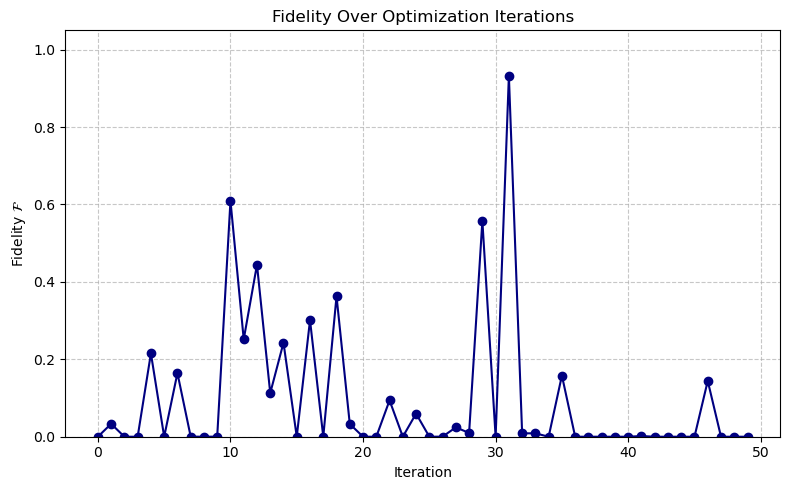

In [186]:
# Extract fidelity from negative objective values
fidelities = [-fval for fval in res.func_vals]  # since obj = -fidelity

# Plot fidelity over iterations
plt.figure(figsize=(8, 5))
plt.plot(fidelities, marker='o', linestyle='-', color='navy')
plt.xlabel('Iteration')
plt.ylabel('Fidelity $\\mathcal{F}$')
plt.title('Fidelity Over Optimization Iterations')
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

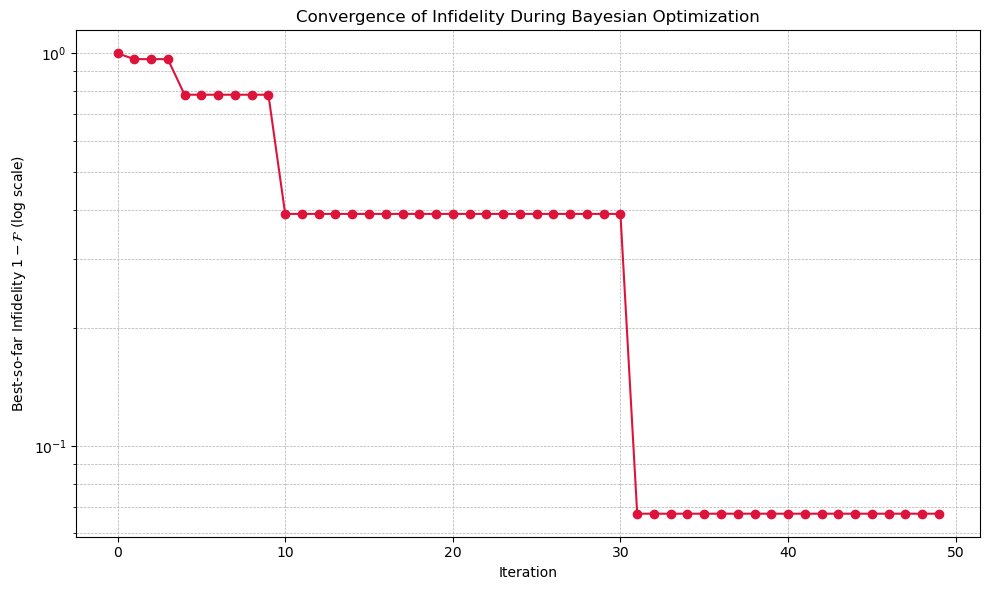

In [187]:
# Extract negative fidelities and compute infidelities
negative_fidelities = np.array(res.func_vals)  # Values are -fidelity
fidelities = -negative_fidelities
infidelities = 1 - fidelities

# Replace zero infidelity with epsilon to avoid log(0)
infidelities[infidelities == 0] = np.finfo(float).eps

# Compute the best (lowest) infidelity so far at each iteration
best_so_far_infidelity = np.minimum.accumulate(infidelities)

# Plot: Convergence of best infidelity
plt.figure(figsize=(10, 6))
plt.semilogy(best_so_far_infidelity, marker='o', linestyle='-', color='crimson')
plt.title("Convergence of Infidelity During Bayesian Optimization")
plt.xlabel("Iteration")
plt.ylabel("Best-so-far Infidelity $1 - \\mathcal{F}$ (log scale)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


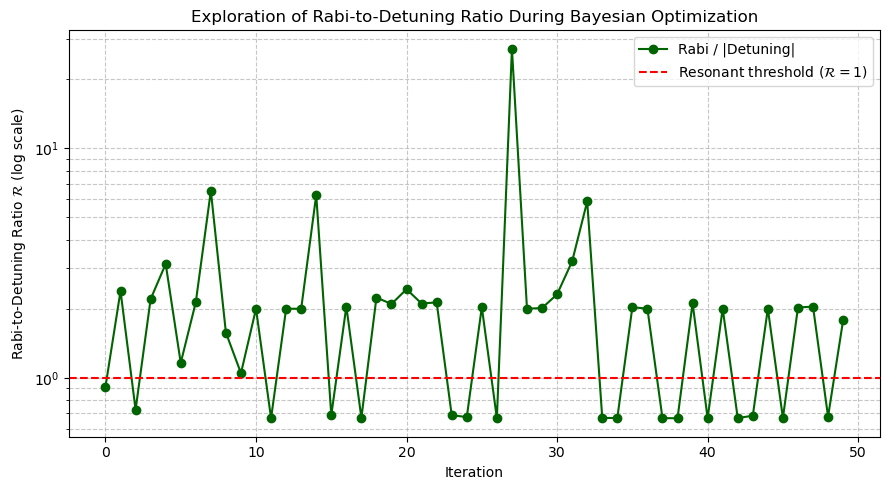

In [188]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
g = 0.01
omega_bare = 2 * g * np.sqrt(1)  # fixed analytical value

# Extract all proposed frequencies from optimizer
frequencies = [x[0] for x in res.x_iters]  # assuming first parameter is frequency

# Compute detunings and ratios over iterations
detunings = np.abs(omega_bare - np.array(frequencies))
rabi_freq = omega_bare
ratios = rabi_freq / detunings

# Plot the ratio over iterations
plt.figure(figsize=(9, 5))
plt.plot(ratios, marker='o', linestyle='-', color='darkgreen', label='Rabi / |Detuning|')
plt.axhline(1.0, color='red', linestyle='--', label='Resonant threshold ($\\mathcal{R}=1$)')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Rabi-to-Detuning Ratio $\\mathcal{R}$ (log scale)')
plt.title('Exploration of Rabi-to-Detuning Ratio During Bayesian Optimization')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [189]:
# Constants
g = 0.01
omega_bare = 2 * g * np.sqrt(5)  # for transition 0↓ -> 5↓

# Extract optimal frequency from optimization result
optimal_frequency = res.x[0]

# Compute detuning and Rabi/Detuning ratio
detuning_optimal = np.abs(omega_bare - optimal_frequency)
rabi_freq = omega_bare
ratio_optimal = rabi_freq / detuning_optimal

# Print everything
print(f"\nOptimal results:")
print(f"Optimal frequency: {optimal_frequency:.5f}")
print(f"Corresponding simulation time: {res.x[-1]:.2f}")
print(f"Rabi frequency: {rabi_freq:.5f}")
print(f"Detuning at optimal point: {detuning_optimal:.5f}")
print(f"Rabi-to-Detuning ratio at optimal point: {ratio_optimal:.5f}")


Optimal results:
Optimal frequency: 0.02621
Corresponding simulation time: 5998.19
Rabi frequency: 0.04472
Detuning at optimal point: 0.01851
Rabi-to-Detuning ratio at optimal point: 2.41649
